## This analysis aims to understand customer behavior in order to implement personalized marketing.

*For a less technical explanation, there is a PowerPoint presentation in the folder*

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

In [2]:
load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    folder = r"C:\Professional_project\Churn_and_Marketing_Analytics\Script_SQL"
    file = "classification_dataset.sql"
    path = os.path.join(folder, file)

    with open(path, 'r', encoding='utf-8') as f:
        sql = f.read()

    engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}',
    connect_args={"sslmode": "require"})

    dataset = pd.read_sql(sql, con=engine)
    print("The data has been successfully loaded!!!")

except FileNotFoundError:
    print(f"The file was not found in the path:{path}")

except Exception as e:
    print(f'--Error details--: {e}')

finally:
    engine.dispose()

The data has been successfully loaded!!!


In [3]:
features = dataset.drop(["customer_unique_id", "customer_state", "total_price", 
"total_freight", "last_purchase", "first_purchase"], axis=1)

In [4]:
features.isnull().sum()

total_paid_items          0
payment_installments      1
total_orders              0
customer_lifetime_days    0
avg_order_value           0
recency_days              0
dtype: int64

In [5]:
features[features["payment_installments"].isna()]

,total_paid_items,payment_installments,total_orders,customer_lifetime_days,avg_order_value,recency_days
48988,143.46,NaN,1,0,143.46,718


In [6]:
features = features.dropna()

### Exploratory data analysis

In [7]:
features.describe()

,total_paid_items,payment_installments,total_orders,customer_lifetime_days,avg_order_value,recency_days
count,95457.000000,95457.000000,95457.000000,95457.000000,95457.000000,95457.000000
mean,173.549806,2.903700,1.033607,2.625412,168.366932,243.539133
std,262.999658,2.678649,0.210014,24.899309,255.575222,153.169117
min,10.070000,0.000000,1.000000,0.000000,10.070000,0.000000
25%,64.000000,1.000000,1.000000,0.000000,63.270000,119.000000
50%,110.630000,2.000000,1.000000,0.000000,107.850000,224.000000
75%,188.360000,4.000000,1.000000,0.000000,182.550000,353.000000
max,13664.080000,24.000000,16.000000,633.000000,13664.080000,729.000000


*Exploratory analysis reveals low purchase frequency. Over 75% of customers made only one purchase, which is reflected in both the distribution of total orders and customer lifetime (days), where the majority of customers have an activity duration of zero days. This suggests that the platform faces retention challenges and that segmentation could help identify profiles with greater loyalty potential.*

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

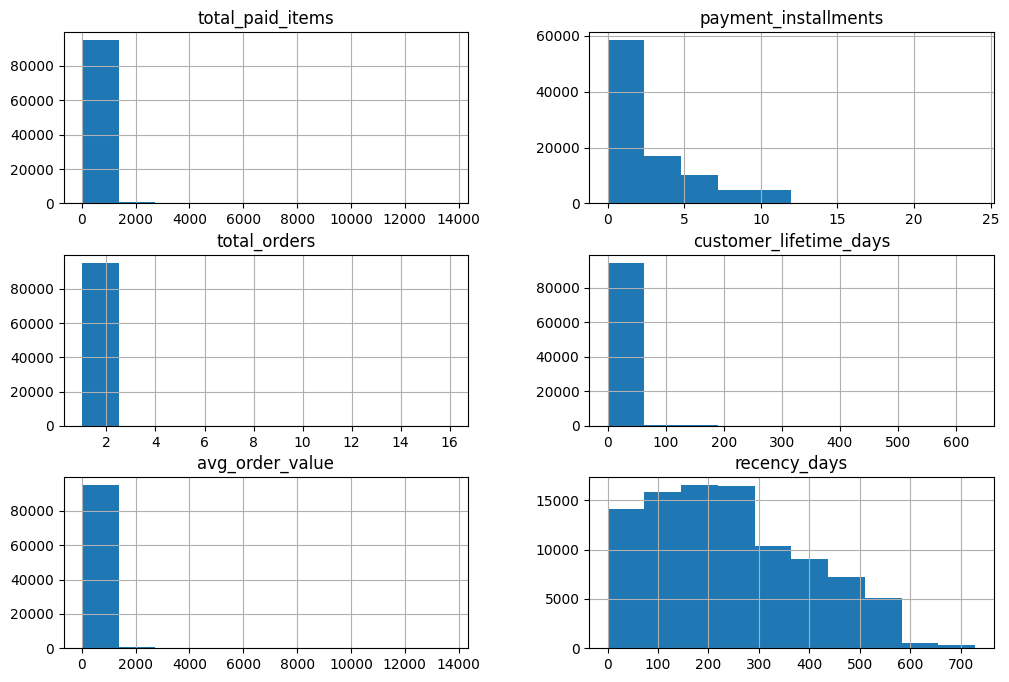

In [9]:
features.hist(figsize=(12,8))
plt.show()

*The Recency variable shows considerable dispersion. There are customers whose last purchase occurred near the end of the analyzed period and others who stopped buying several hundred days earlier, suggesting different levels of activity and possible churn.*

<Axes: >

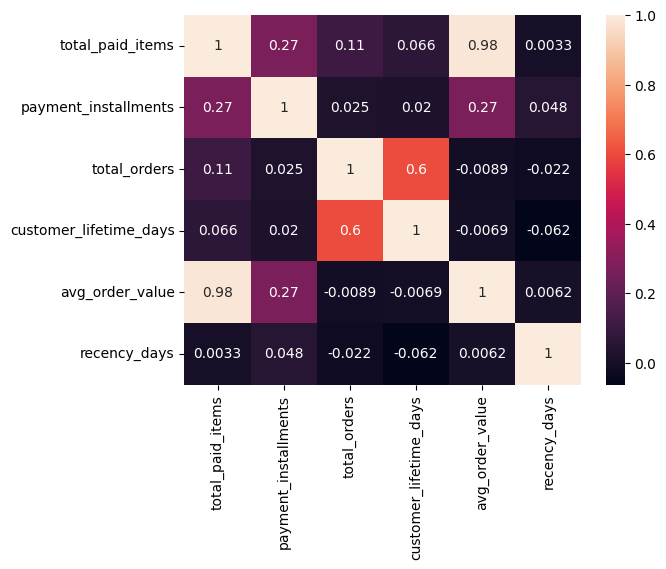

In [10]:
sns.heatmap(features.corr(), annot=True)

<Axes: xlabel='total_orders', ylabel='total_paid_items'>

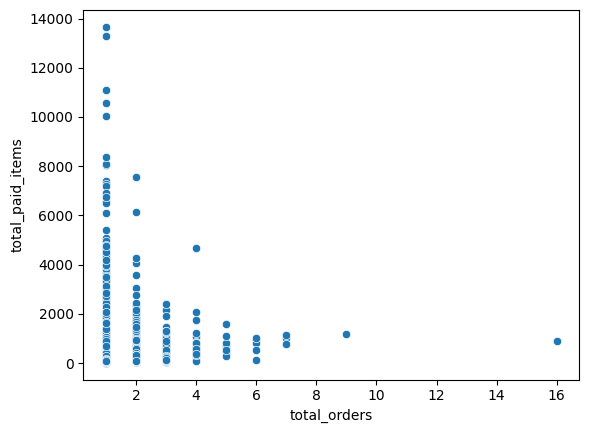

In [11]:
sns.scatterplot(data=features, x="total_orders", y="total_paid_items")

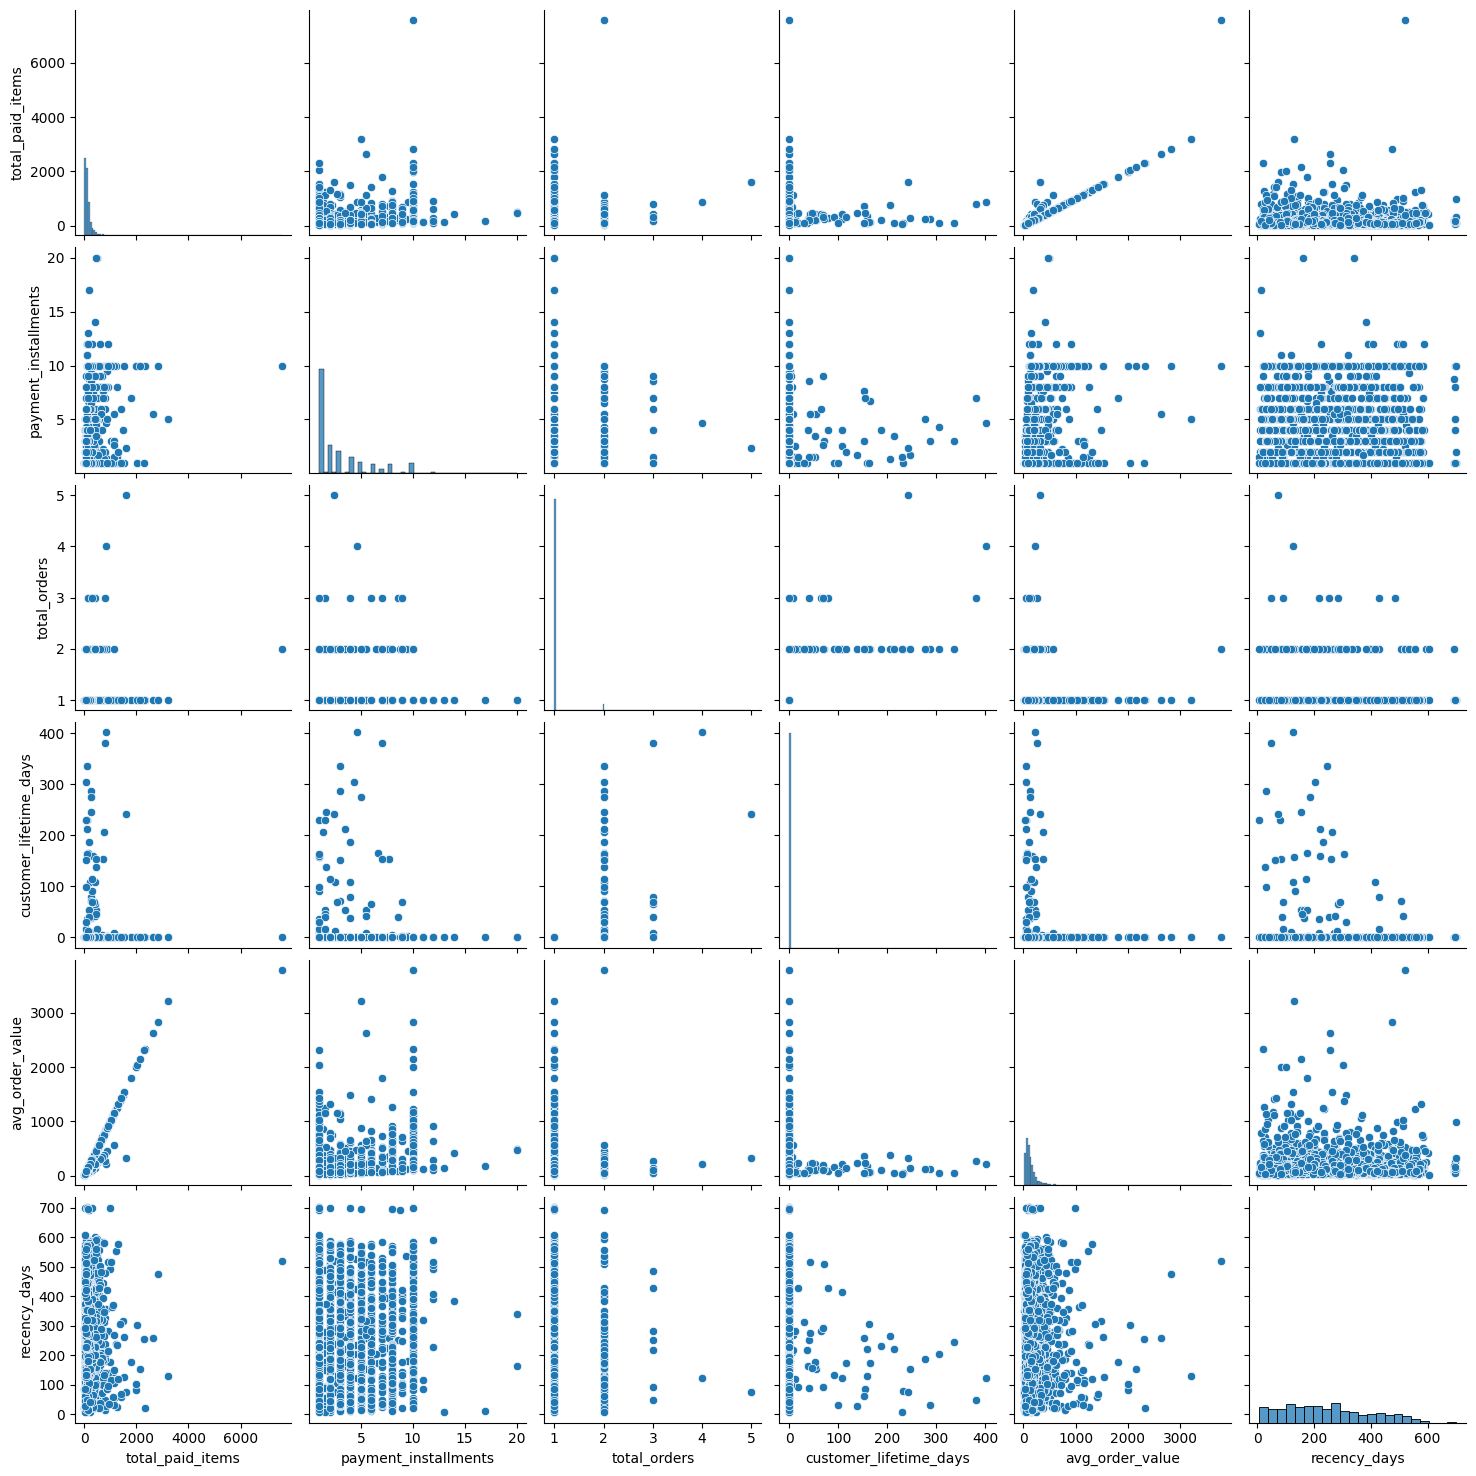

In [12]:
sns.pairplot(
    features.sample(3000))

### Variable selection and outlier handling

In [13]:
ml_df = features.drop("avg_order_value", axis=1)

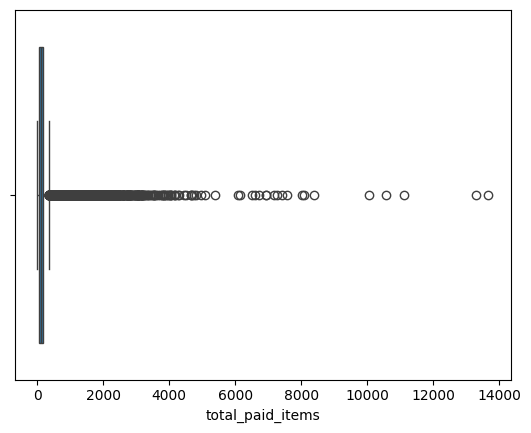

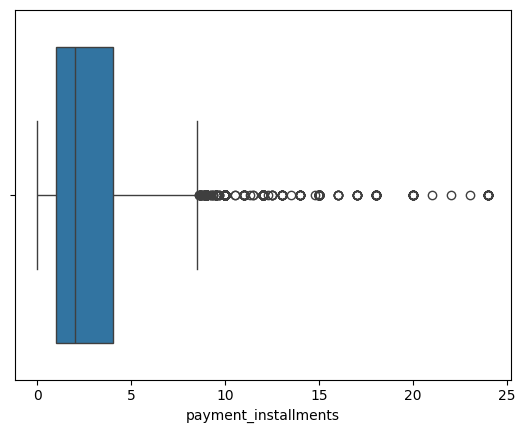

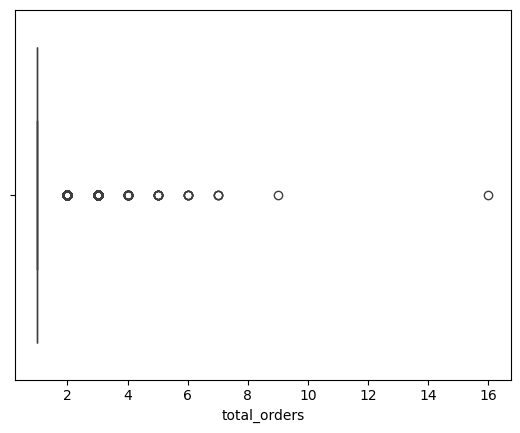

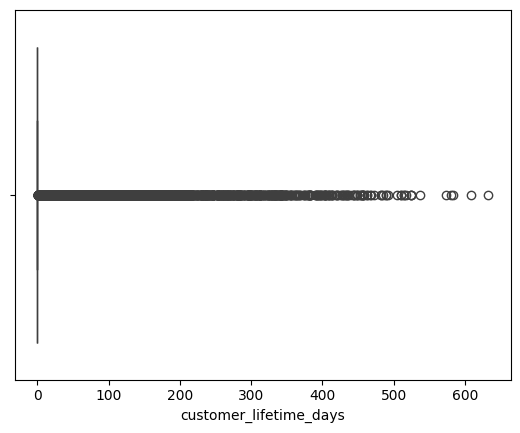

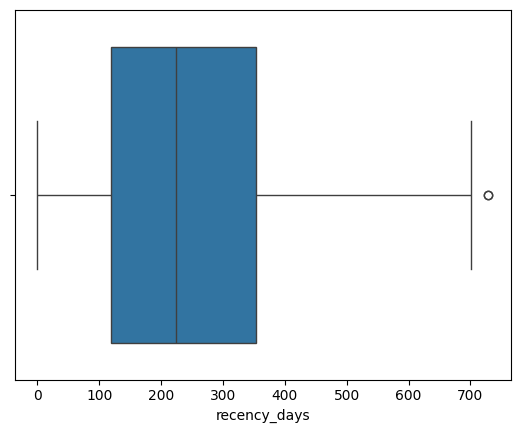

In [14]:
for col in ml_df.columns:
    sns.boxplot(x=ml_df[col])
    plt.show()

### Log Transform and standardisation

In [15]:
import numpy as np

In [16]:
ml_df["total_paid_items"] = np.log1p(ml_df["total_paid_items"])

ml_df["customer_lifetime_days"] = np.log1p(ml_df["customer_lifetime_days"])

*Due to the strong positive skewness observed in total_paid_items and customer_lifetime_days, a logarithmic transformation (log1p) was applied. This transformation reduces the influence of extreme values while preserving the relative differences between customers, improving the performance of distance-based clustering algorithms such as K-Means.*

<Axes: xlabel='total_paid_items'>

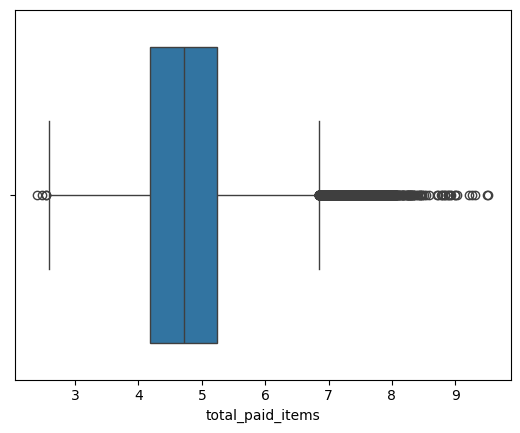

In [17]:
sns.boxplot(x=ml_df["total_paid_items"])


<Axes: xlabel='customer_lifetime_days'>

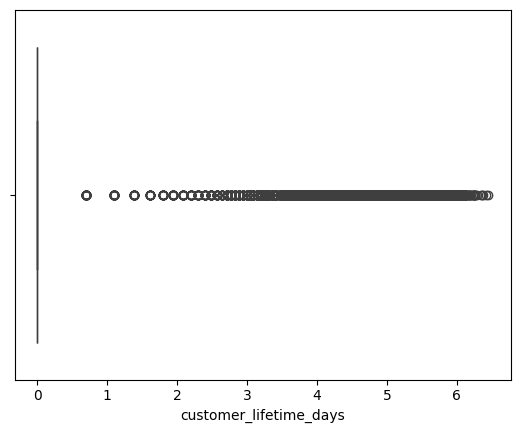

In [18]:
sns.boxplot(x=ml_df["customer_lifetime_days"])

Text(0.5, 1.0, 'Log1p')

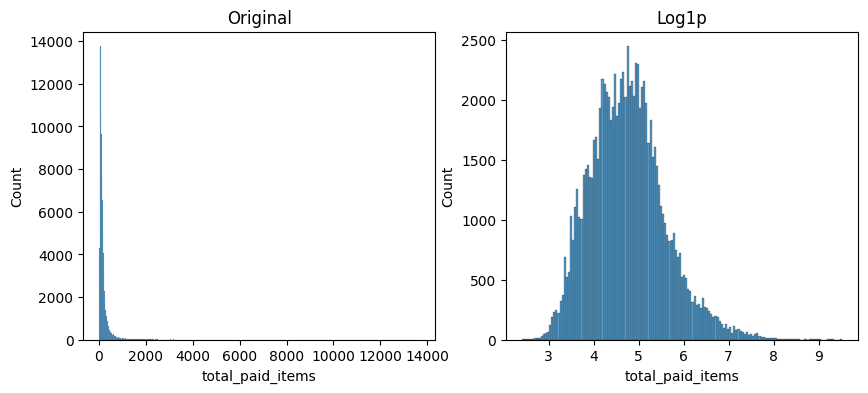

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(dataset["total_paid_items"], ax=ax[0])
ax[0].set_title("Original")

sns.histplot(ml_df["total_paid_items"], ax=ax[1])
ax[1].set_title("Log1p")

## KMeans Model

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(ml_df)

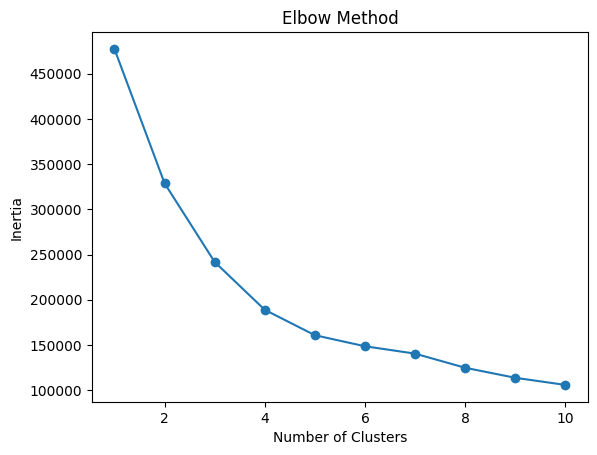

In [35]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig(
    r"C:\Professional_project\Churn_and_Marketing_Analytics\Images\elbow_method_classification.png",
    bbox_inches="tight")

plt.show()

*The elbow method suggests that the clusters that yield the greatest segmentation are between cluster 4 and 6.*

In [22]:
from sklearn.metrics import silhouette_score

In [23]:
sample = pd.DataFrame(X_scaled).sample(
    n=15000,
    random_state=42)

In [24]:
results = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(sample)

    score = silhouette_score(sample, labels)

    results.append({
        "k": k,
        "silhouette_score": score
    })

results_df = pd.DataFrame(results)
results_df

,k,silhouette_score
0,2,0.709204
1,3,0.361609
2,4,0.306044
3,5,0.292526
4,6,0.302456


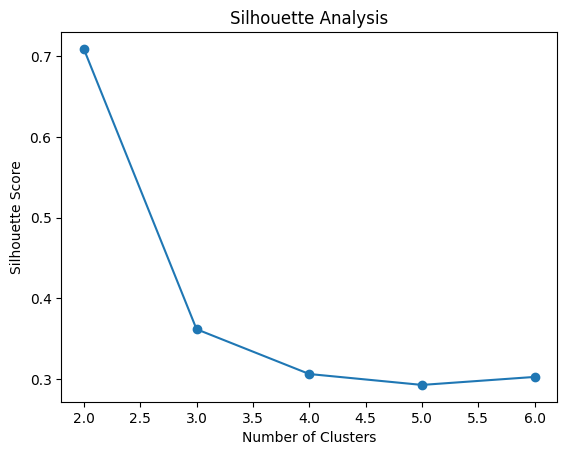

In [25]:
plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [26]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
ml_df["cluster_2"] = kmeans_2.fit_predict(X_scaled)

In [27]:
ml_df.groupby("cluster_2")[["total_paid_items", "payment_installments", 
                           "total_orders", "customer_lifetime_days", "recency_days"]].mean()

,total_paid_items,payment_installments,total_orders,customer_lifetime_days,recency_days
cluster_2,,,,,
0,4.738543,2.897613,1.009045,0.000353,244.541243
1,5.555031,3.183116,2.161179,4.182113,197.534644


In [28]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

ml_df["cluster_4"] = kmeans_4.fit_predict(X_scaled)

In [29]:
ml_df.groupby("cluster_4")[
    [
        "total_paid_items",
        "payment_installments",
        "total_orders",
        "customer_lifetime_days",
        "recency_days"
    ]
].mean()

,total_paid_items,payment_installments,total_orders,customer_lifetime_days,recency_days
cluster_4,,,,,
0,5.593471,7.562360,1.018547,0.001051,247.957199
1,4.543153,1.985666,1.009255,0.000305,399.164319
2,5.552122,3.163897,2.161975,4.197540,197.515556
3,4.556529,1.795144,1.005561,0.000360,134.358115


*Although K=2 obtained the highest Silhouette Score, K=4 was selected because it provides more interpretable and actionable segments from a business perspective, allowing the identification of different customer profiles and the design of specific strategies for each of them.*

In [30]:
ml_df["cluster_4"].value_counts(normalize=True) * 100

cluster_4
3    47.091361
1    33.164671
0    17.622594
2     2.121374
Name: proportion, dtype: float64

*Approximately 80% of customers (Clusters 1 and 3) made a single purchase and are primarily distinguished by the time elapsed since their last purchase. In contrast, only 2% belong to the repeat customer segment, which has the highest purchase frequency and the longest relationship duration with the platform.*

*That 2.12% seems particularly interesting to me because it confirms what we observed during the exploratory analysis: most people buy once, but there is a small group that does generate repeat purchases. This group is usually the primary target of loyalty and retention strategies.*

In [31]:
cluster_names = {
    0: "High Value One-Time",
    1: "Dormant Customers",
    2: "Loyal Customers",
    3: "Recent Customers"
}

ml_df["segment"] = ml_df["cluster_4"].map(cluster_names)

In [32]:
sample_idx = np.random.choice(
    len(X_scaled),
    size=15000,
    replace=False
)

X_sample = X_scaled[sample_idx]

cluster_sample_named = ml_df["segment"].iloc[sample_idx]

In [33]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

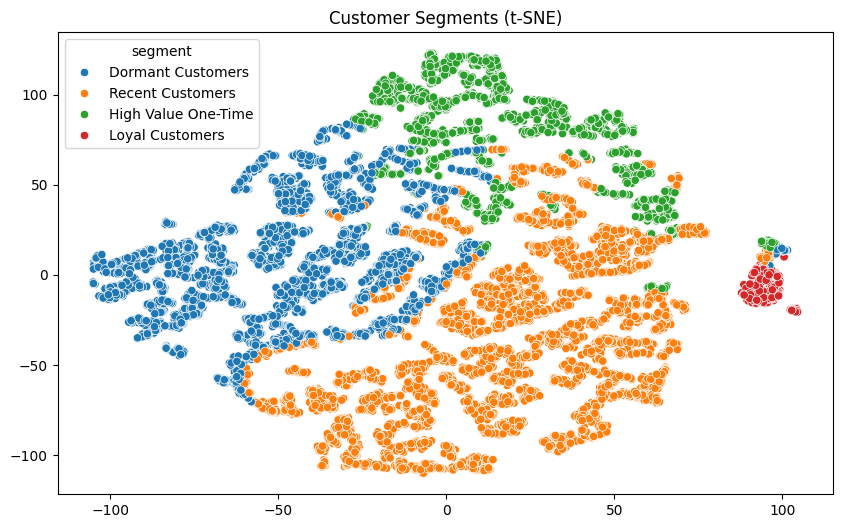

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=cluster_sample_named,
    palette="tab10"
)

plt.title("Customer Segments (t-SNE)")

plt.savefig(
    r"C:\Professional_project\Churn_and_Marketing_Analytics\Images\customer_segments_classification.png",
    bbox_inches="tight")

plt.show()

*K-Means identified four customer segments with distinct behaviors. The Loyal Customers segment showed the greatest separation from the other groups, indicating recurring purchase patterns and a longer relationship with the platform. The Recent Customers, Dormant Customers, and High Value One-Time segments showed some overlap, suggesting that some customers share similar characteristics and that purchasing behavior exists on a spectrum rather than in completely isolated categories.*